In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("../data/processed/avis.csv")

In [3]:
X = df['clean_text']
y = df['note']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [5]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.60      0.86      0.71      1411
         2.0       0.36      0.17      0.23       773
         3.0       0.34      0.18      0.23       685
         4.0       0.43      0.50      0.46       937
         5.0       0.59      0.57      0.58      1008

    accuracy                           0.52      4814
   macro avg       0.46      0.46      0.44      4814
weighted avg       0.49      0.52      0.49      4814



In [6]:
rf = RandomForestClassifier()
rf.fit(X_train_tfidf, y_train)

y_pred = rf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.53      0.97      0.68      1444
         2.0       0.36      0.01      0.01       722
         3.0       0.39      0.03      0.05       689
         4.0       0.43      0.44      0.43       982
         5.0       0.52      0.59      0.55       977

    accuracy                           0.50      4814
   macro avg       0.44      0.41      0.35      4814
weighted avg       0.46      0.50      0.42      4814



In [7]:
svm = SVC()
svm.fit(X_train_tfidf, y_train)

y_pred = svm.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.58      0.96      0.73      1444
         2.0       0.33      0.05      0.08       722
         3.0       0.38      0.15      0.21       689
         4.0       0.45      0.51      0.48       982
         5.0       0.57      0.57      0.57       977

    accuracy                           0.53      4814
   macro avg       0.46      0.45      0.41      4814
weighted avg       0.49      0.53      0.47      4814



In [9]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df['clean_text'].tolist())

c:\Users\anton\anaconda3\envs\py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\anton\anaconda3\envs\py312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anton\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order

In [ ]:
import numpy as np

np.save("../models/embeddings.npy", embeddings)

In [ ]:
embeddings = np.load("../models/embeddings.npy")

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

query = model.encode(["service client horrible"])

scores = cosine_similarity(query, embeddings)[0]

top_idx = scores.argsort()[-5:][::-1]

df.iloc[top_idx][['avis', 'note']]

,avis,note
5673,Un Service client déplorable.,2.0
2072,Service client DEPLORABLE.,1.0
4710,SERVICE CLIENT INEXISTANT,1.0
11615,Service Client inexistant,2.0
20592,"Service client vraiment disponible, et a l'écoute",5.0


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

def search(query, top_k=5):
    query_vec = model.encode([query])
    scores = cosine_similarity(query_vec, embeddings)[0]
    
    top_idx = scores.argsort()[-top_k:][::-1]
    return df.iloc[top_idx][['avis', 'note']]

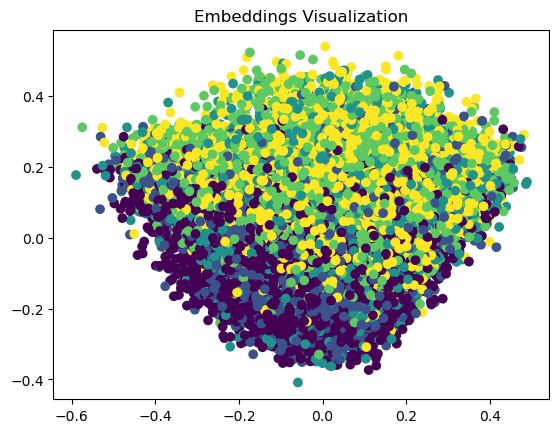

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.scatter(reduced[:,0], reduced[:,1], c=df['note'])
plt.title("Embeddings Visualization")
plt.show()

In [23]:
from bertopic import BERTopic

topic_model = BERTopic()
topics, probs = topic_model.fit_transform(df['clean_text'])

df['topic'] = topics

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6033.28it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
import joblib

joblib.dump(lr, "../models/logistic_regression.pkl")
joblib.dump(tfidf, "../models/tfidf.pkl")

['../models/tfidf.pkl']